# Deep Learning Assignment — Practice 2: RNNs

| | |
|---|---|
| **Students** | Gianluca Lascaro, Raffaele Rizzuti |
| **University** | Universidad de A Coruña |
| **Year** | 2025–2026 |

## 1. Data Preprocessing
Steps to prepare the dataset for training:
1. **Cleaning**: Discard anomalous data (year 2026).
2. **Temporal Split**: Chronological split for Train (2021-2023), Validation (2024), and Test (2025).
3. **Normalization**: Z-score scaling based on the training set.
4. **Sequencing**: Creating 24-hour sliding windows to predict total load 3 hours ahead.

In [1]:
import numpy as np
import pandas as pd

# Load and clean
df = pd.read_csv("nyiso_hourly_load.csv", parse_dates=["Time Stamp"])
df = df[df["Time Stamp"].dt.year < 2026].copy()

# Temporal split
FEATURE_COLS = [c for c in df.columns if c != "Time Stamp"]
TARGET_COL = "total_load"

train = df[df["Time Stamp"].dt.year <= 2023].copy()
val = df[df["Time Stamp"].dt.year == 2024].copy()
test = df[df["Time Stamp"].dt.year == 2025].copy()

In [2]:
# Normalization (Z-score)
mean = train[FEATURE_COLS].mean()
std = train[FEATURE_COLS].std()

train_scaled = train[FEATURE_COLS].sub(mean).div(std)
val_scaled = val[FEATURE_COLS].sub(mean).div(std)
test_scaled = test[FEATURE_COLS].sub(mean).div(std)

In [3]:
def make_sequences(data, seq_len=24, horizon=3, target_idx=-1):
    """Creates sequences (X) and targets (y)."""
    X, y = [], []
    for i in range(len(data) - seq_len - horizon + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len + horizon - 1, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

SEQ_LEN = 24
X_train, y_train = make_sequences(train_scaled.values, SEQ_LEN)
X_val, y_val = make_sequences(val_scaled.values, SEQ_LEN)
X_test, y_test = make_sequences(test_scaled.values, SEQ_LEN)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Train: (26081, 24, 12), (26081,)
Val:   (8758, 24, 12), (8758,)
Test:  (8734, 24, 12), (8734,)


## 2. Baseline Models
Evaluation of simple heuristics and a basic neural network to establish performance benchmarks.
- **Metric**: Mean Absolute Error (MAE), computed on denormalized data (Megawatts).
- **Models**:
  1. **Last-value**: Predicts the last observed hour in the sequence.
  2. **Daily**: Predicts the value from exactly 24 hours prior.
  3. **Neural (Conv1D)**: A simple 1D Convolutional network to capture local temporal patterns.

In [4]:
from sklearn.metrics import mean_absolute_error

# Denormalization parameters for the target
target_mean = mean[TARGET_COL]
target_std = std[TARGET_COL]

def evaluate_mae(y_true_norm, y_pred_norm):
    """Converts normalized values back to Megawatts and computes MAE."""
    y_true_denorm = (y_true_norm * target_std) + target_mean
    y_pred_denorm = (y_pred_norm * target_std) + target_mean
    return mean_absolute_error(y_true_denorm, y_pred_denorm)

In [5]:
TARGET_IDX = -1

# 1. Last-value Baseline (last step of the 24h sequence)
y_pred_last = X_test[:, -1, TARGET_IDX]
mae_last = evaluate_mae(y_test, y_pred_last)

# 2. Daily Baseline (24h before the target -> index 2 in the sequence)
y_pred_daily = X_test[:, 2, TARGET_IDX]
mae_daily = evaluate_mae(y_test, y_pred_daily)

print(f"Last-value Baseline MAE: {mae_last:.2f} MW")
print(f"Daily Baseline MAE:      {mae_daily:.2f} MW")

Last-value Baseline MAE: 1399.58 MW
Daily Baseline MAE:      1005.23 MW


2026-04-23 16:24:27.758614: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 16:24:27.881380: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 16:24:32.108936: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


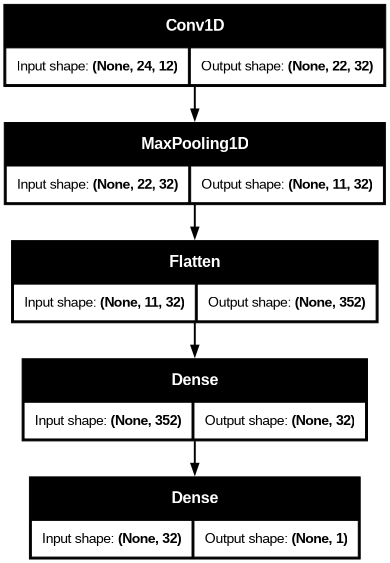

Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2033 - val_loss: 0.1769
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1352 - val_loss: 0.1493
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1198 - val_loss: 0.1368
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1126 - val_loss: 0.1296
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1080 - val_loss: 0.1387
Epoch 6/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1037 - val_loss: 0.1215
Epoch 7/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1042 - val_loss: 0.1291
Epoch 8/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0991 - val_loss: 0.1168
Epoch 9/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0979 - val_loss: 0.1149
Epoch 10/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0956 - val_loss: 0.1106
Epoch 11/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0931 - val_loss: 0.1107
Epoch 12/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import plot_model

# 3. Neural Baseline (Conv1D)
neural_baseline = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

neural_baseline.compile(optimizer='adam', loss='mae')

# Display Model Architecture natively without visualkeras
display(plot_model(neural_baseline, show_shapes=True, show_layer_names=False, dpi=70))

# Train
history = neural_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)

# Evaluate
y_pred_neural = neural_baseline.predict(X_test).flatten()
mae_neural = evaluate_mae(y_test, y_pred_neural)

print(f"Neural Baseline (Conv1D) MAE: {mae_neural:.2f} MW")